# Разработка A/B-тестирования и анализ результатов

В этом проекте мы анализируем развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В нашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. 

Наша цель – рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

В нашем распоряжении 3 таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать

Наши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

На первом этапе поработаем с историческими данными приложения:

In [1]:
import pandas as pd

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Для каждого уникального пользователя user_id рассчитаем количество уникальных сессий session_id
sessions_per_user = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
    .reset_index(name='sessions_count')
)

sessions_per_user.head()

,user_id,sessions_count
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2


In [5]:
# Выведем на экран все данные из таблицы sessions_history для одного пользователя с наибольшим количеством сессий
top_user_id = sessions_per_user.sort_values('sessions_count', ascending=False).iloc[0]['user_id']

# Выведем все данные по этому пользователю
top_user_data = sessions_history[sessions_history['user_id'] == top_user_id]

top_user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

In [6]:
import matplotlib.pyplot as plt

In [7]:
# Дата
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [8]:
# Все пользователи по дням
daily_users = (
    sessions_history
    .groupby('session_date')['user_id']
    .nunique()
    .reset_index(name='users')
)

In [9]:
# Только зарегистрированные пользователи
registered_daily = (
    sessions_history[sessions_history['registration_flag'] == 1]
    .groupby('session_date')['user_id']
    .nunique()
    .reset_index(name='registered_users')
)

In [10]:
# Объединяем
registrations_daily = daily_users.merge(
    registered_daily,
    on='session_date',
    how='left'
)

In [11]:
# Заполняем пропуски (если в день не было регистраций)
registrations_daily['registered_users'] = registrations_daily['registered_users'].fillna(0)

In [12]:
# Доля
registrations_daily['registered_share'] = (
    registrations_daily['registered_users'] / registrations_daily['users']
)

In [13]:
registrations_daily.head()

,session_date,users,registered_users,registered_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


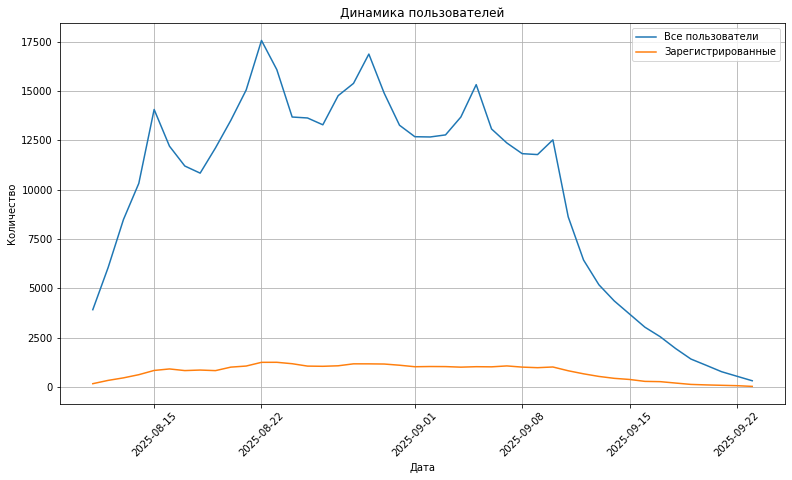

In [14]:
# линейный график общего числа пользователей и общего числа зарегистрированных пользователей по дням
plt.figure(figsize=(13, 7))

plt.plot(registrations_daily['session_date'], registrations_daily['users'], label='Все пользователи')
plt.plot(registrations_daily['session_date'], registrations_daily['registered_users'], label='Зарегистрированные')

plt.title('Динамика пользователей')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

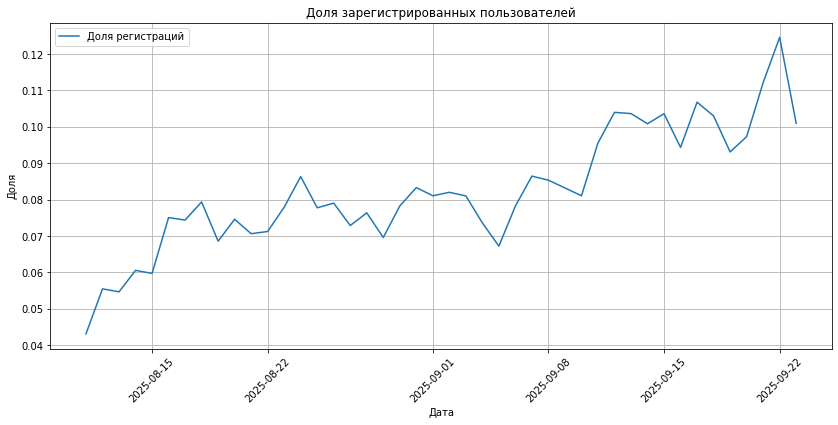

In [15]:
# график доли зарегистрированных пользователей от всех пользователей по дням
plt.figure(figsize=(14, 6))

plt.plot(registrations_daily['session_date'], registrations_daily['registered_share'], label='Доля регистраций')

plt.title('Доля зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### 1.4. Анализ числа просмотренных страниц

Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

In [16]:
# отбираем первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [17]:
# считаем распределение просмотров страниц
pages_distribution = (
    first_sessions
    .groupby('page_counter')['session_id']
    .count()
    .reset_index(name='sessions_count')
    .sort_values('page_counter')
)

pages_distribution.head()

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075


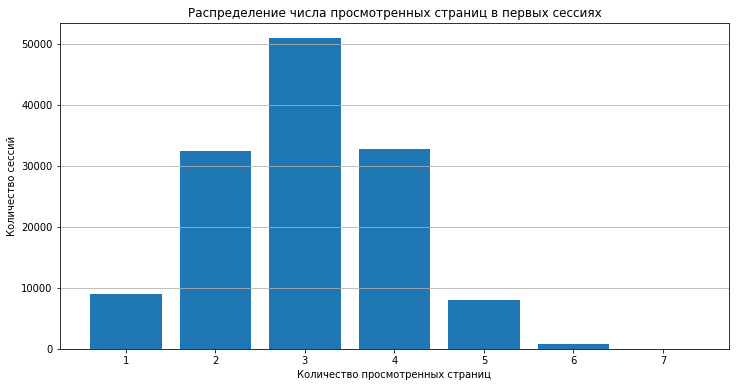

In [18]:
# строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

plt.bar(
    pages_distribution['page_counter'],
    pages_distribution['sessions_count']
)

plt.title('Распределение числа просмотренных страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')

plt.grid(axis='y')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

In [19]:
# cоздаём признак успешной сессии
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

In [20]:
# оставляем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()


In [21]:
# дата
first_sessions['session_date'] = pd.to_datetime(first_sessions['session_date'])

In [22]:
# средняя доля успешных первых сессий по дням
good_sessions_daily = (
    first_sessions
    .groupby('session_date')['good_session']
    .mean()
    .reset_index(name='good_session_share')
)

good_sessions_daily.head()

,session_date,good_session_share
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114


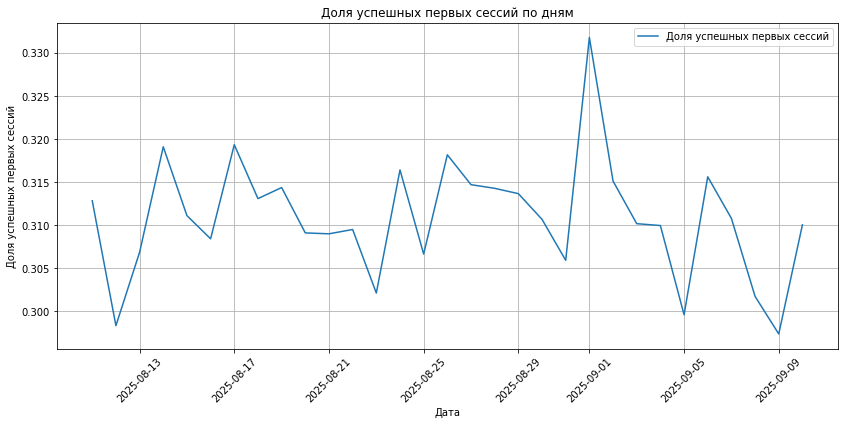

In [23]:
# построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей.
plt.figure(figsize=(14, 6))

plt.plot(
    good_sessions_daily['session_date'],
    good_sessions_daily['good_session_share'],
    label='Доля успешных первых сессий'
)

plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки

In [24]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаем параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

In [25]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным 
avg_daily_users = (
    sessions_history
    .groupby('session_date')['user_id']
    .nunique()
    .mean()
)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [26]:
# считываем данные первого дня теста
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [27]:
# количество уникальных пользователей по группам
users_by_group = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='users_count')
)

users_by_group

,test_group,users_count
0,A,1477
1,B,1466


In [28]:
# достаём значения для групп A и B
users_A = users_by_group.loc[users_by_group['test_group'] == 'A', 'users_count'].iloc[0]
users_B = users_by_group.loc[users_by_group['test_group'] == 'B', 'users_count'].iloc[0]

# процентная разница
percent_diff = 100 * abs(users_A - users_B) / users_A

print(f'Количество пользователей в группе A: {users_A}')
print(f'Количество пользователей в группе B: {users_B}')
print(f'Процентная разница между группами: {percent_diff:.2f}%')

Количество пользователей в группе A: 1477
Количество пользователей в группе B: 1466
Процентная разница между группами: 0.74%


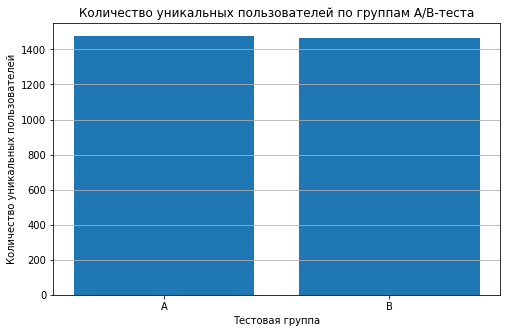

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    users_by_group['test_group'],
    users_by_group['users_count']
)

plt.title('Количество уникальных пользователей по группам A/B-теста')
plt.xlabel('Тестовая группа')
plt.ylabel('Количество уникальных пользователей')
plt.grid(axis='y')

plt.show()

#### 3.2. Проверка пересечений пользователей

Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [30]:
# пользователи группы A
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])

In [31]:
# пользователи группы B
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

In [32]:
# пересечение пользователей
users_intersection = users_A.intersection(users_B)

In [33]:
print(f'Количество пользователей, попавших одновременно в группы A и B: {len(users_intersection)}')

Количество пользователей, попавших одновременно в группы A и B: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

In [34]:
# доля устройств в каждой группе
device_share = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .reset_index(name='users_count')
)

device_share['device_share'] = (
    device_share['users_count']
    / device_share.groupby('test_group')['users_count'].transform('sum')
)

device_share

,test_group,device,users_count,device_share
0,A,Android,656,0.444144
1,A,Mac,156,0.105619
2,A,PC,369,0.249831
3,A,iPhone,296,0.200406
4,B,Android,668,0.455662
5,B,Mac,148,0.100955
6,B,PC,381,0.259891
7,B,iPhone,269,0.183492


In [35]:
# Отдельные датафреймы для A и B
device_share_A = device_share[device_share['test_group'] == 'A']
device_share_B = device_share[device_share['test_group'] == 'B']

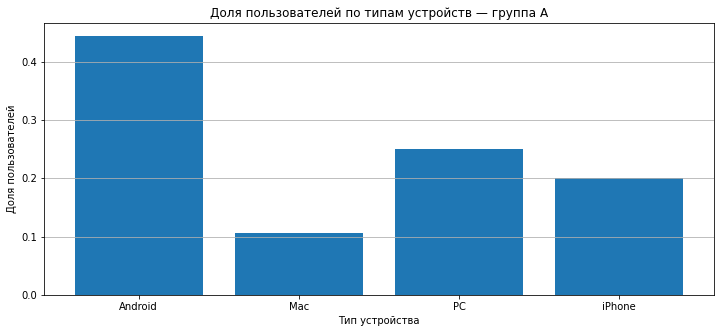

In [36]:
# столбчатая диаграмма – доля каждого типа устройства для пользователей из группы A
plt.figure(figsize=(12, 5))

plt.bar(
    device_share_A['device'],
    device_share_A['device_share']
)

plt.title('Доля пользователей по типам устройств — группа A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(axis='y')

plt.show()

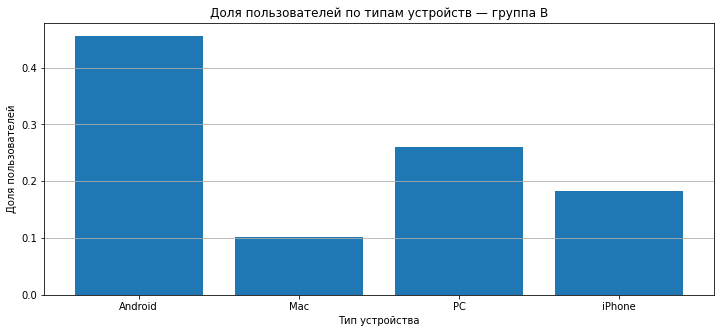

In [37]:
# столбчатая диаграмма – доля каждого типа устройства для пользователей из группы B
plt.figure(figsize=(12, 5))

plt.bar(
    device_share_B['device'],
    device_share_B['device_share']
)

plt.title('Доля пользователей по типам устройств — группа B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(axis='y')

plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [38]:
# доля регионов в каждой группе
region_share = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .reset_index(name='users_count')
)

region_share['region_share'] = (
    region_share['users_count']
    / region_share.groupby('test_group')['users_count'].transform('sum')
)

region_share

,test_group,region,users_count,region_share
0,A,CIS,644,0.436019
1,A,EU,224,0.151659
2,A,MENA,609,0.412322
3,B,CIS,645,0.439973
4,B,EU,217,0.148022
5,B,MENA,604,0.412005


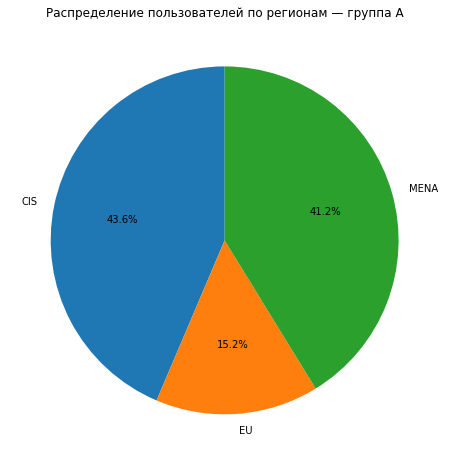

In [39]:
# группа A
region_share_A = region_share[region_share['test_group'] == 'A']

plt.figure(figsize=(8, 8))

plt.pie(
    region_share_A['region_share'],
    labels=region_share_A['region'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Распределение пользователей по регионам — группа A')
plt.show()

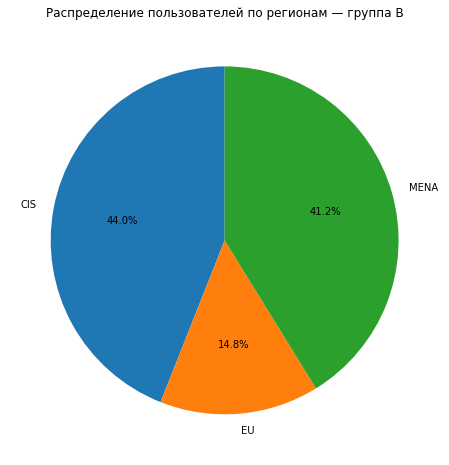

In [40]:
# группа B
region_share_B = region_share[region_share['test_group'] == 'B']

plt.figure(figsize=(8, 8))

plt.pie(
    region_share_B['region_share'],
    labels=region_share_B['region'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Распределение пользователей по регионам — группа B')
plt.show()

#### 3.5. Вывод после проверки A/B-теста

**Вывод:**

На этапе мониторинга A/B-теста было проверено распределение пользователей между группами A и B.

Количество пользователей в группах практически одинаковое:
- в группе A — 1477 пользователей,
- в группе B — 1466 пользователей.
Процентная разница составляет 0.74%, что говорит об отсутствии значимого перекоса.

Пересечений пользователей между группами не обнаружено:
- количество пользователей, попавших одновременно в A и B — 0.
Это подтверждает независимость выборок.

Распределение пользователей по устройствам в группах A и B совпадает:
- различия по долям минимальны.

Распределение по регионам также равномерное:
- различия между группами незначительные.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [41]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [42]:
# cоздаём признак успешной сессии
sessions_test['good_session'] = (
    sessions_test['page_counter'] >= 4
).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

**Целевая метрика:**

доля успешных первых сессий, то есть доля сессий, где пользователь просмотрел 4 и более страниц.

**Нулевая гипотеза H₀:**
    
новый алгоритм рекомендаций не изменил долю успешных первых сессий.
То есть доля good_session в группе B равна доле good_session в группе A.

**Альтернативная гипотеза H₁:**
    
новый алгоритм рекомендаций увеличил долю успешных первых сессий.
То есть доля good_session в группе B выше, чем в группе A.

**Прокси-метрики:**
    
- среднее количество просмотренных страниц за сессию;
- длительность сессии;
- число сессий на пользователя;
- retention rate

**Барьерные метрики:**
    
- отток пользователей;
- технические ошибки и падения приложения.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [43]:
# оставляем только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

In [44]:
# считаем долю успешных сессий по группам
good_session_share = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .mean()
    .reset_index(name='good_session_share')
)

good_session_share

,test_group,good_session_share
0,A,0.315724
1,B,0.314673


In [45]:
# достаём значения
share_A = good_session_share.loc[good_session_share['test_group'] == 'A', 'good_session_share'].iloc[0]
share_B = good_session_share.loc[good_session_share['test_group'] == 'B', 'good_session_share'].iloc[0]

In [46]:
# разница
diff = share_B - share_A

print(f'Доля успешных первых сессий в группе A: {share_A:.4f}')
print(f'Доля успешных первых сессий в группе B: {share_B:.4f}')
print(f'Разница (B - A): {diff:.4f}')

Доля успешных первых сессий в группе A: 0.3157
Доля успешных первых сессий в группе B: 0.3147
Разница (B - A): -0.0011


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

In [47]:
# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

# Размеры выборок
n_a = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].count()
n_b = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].count()

# Количество успехов
m_a = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].sum()
m_b = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].sum()

alpha = 0.05  # уровень значимости

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'  # H1: p_A < p_B
)

print(f'p-value: {p_value_ztest}')

if p_value_ztest > alpha:
    print(f'pvalue = {p_value_ztest:.5f} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue = {p_value_ztest:.5f} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

p-value: 0.5783523649187868
pvalue = 0.57835 > 0.05
Нулевая гипотеза находит подтверждение!


#### 4.5. Вывод по результатам A/B-эксперимента

A/B-тест проводился в течение 20 дней.
В эксперименте приняли участие:
- группа A: 15 162 пользователей
- группа B: 15 416 пользователей

Ключевая метрика — доля успешных первых сессий (с ≥ 4 просмотрами страниц):
- в группе A: 0.3157 (31.57%)
- в группе B: 0.3147 (31.47%)

Разница между группами составила: −0.0011, то есть в тестовой группе метрика даже немного ниже.
Для проверки статистической значимости был проведён Z-тест.

Полученное значение p-value = 0.57835.

Так как p-value значительно больше уровня значимости 0.05, у нас нет оснований отвергнуть нулевую гипотезу. Это означает, что наблюдаемое различие является случайным и статистически незначимым.

**Заключение:**
Новый алгоритм рекомендаций не показал улучшения ключевой метрики. Более того, наблюдается незначительное снижение, которое не является статистически значимым.

**Рекомендация:**
В текущем виде алгоритм не стоит внедрять в продакшн, так как он не улучшает пользовательскую вовлечённость.